# Fuel equilibrium
Find fuel equilibrium.

In [1]:
# Reload Process each time (keep editable install up-to-date)
%load_ext autoreload
%autoreload 2
from IPython.display import clear_output
from process.main import SingleRun
import process.data_structure
import process.impurity_radiation as impurity_radiation
import process.constraints
import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import matplotlib.colors
import process.physics
import pandas as pd
import seaborn as sns
from process.io.plot_solutions import (
    RunMetadata,
    plot_mfile_solutions,
    plot_mfile_solutions_constraints,
)
from pathlib import Path

Running scipy's SLSQP


Running without any radiation modifications solves: replicate for now.

In [2]:
# Control vars to move solution vector
P_HCD_PRIMARY_EXTRA_HEAT_MW = 200.0
MOLFLOW_PLASMA_FUELLING_REQUIRED = 7.5e21

In [3]:
# Set up
INPUT_FILE = "data/lt_solve_fuel_IN.DAT"
single_run = SingleRun(INPUT_FILE)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = (
    5.0e-6
)
process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = (
    P_HCD_PRIMARY_EXTRA_HEAT_MW
)
process.data_structure.physics_variables.hfact = 1.0

process.data_structure.physics_variables.nd_plasma_electrons_vol_avg = 9.0e19
process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev = 11.0
process.data_structure.physics_variables.molflow_plasma_fuelling_required = (
    MOLFLOW_PLASMA_FUELLING_REQUIRED
)

single_run.run()
clear_output()
print(f"{single_run.scan.ifail = }")

single_run.scan.ifail = 1


In [4]:
ne_sol = process.data_structure.physics_variables.nd_plasma_electrons_vol_avg
te_sol = process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev
print(f"ne = {ne_sol:.3e}")
print(f"te = {te_sol:.3e}")

ne = 8.136e+19
te = 1.161e+01


This solution appears reasonable.

## Visualising constraints
Evaluate constraints.

In [5]:
# Set up
input_file = "data/lt_eval_fuel_IN.DAT"
single_run = SingleRun(input_file)
process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[13] = (
    5.0e-6
)

# Study set up
N = 7
ne = np.linspace(7.0e19, 1.1e20, num=N)
te = np.linspace(8.0, 14.0, num=N)
ne_grid, te_grid = np.meshgrid(ne, te)


# Evaluation func
def eval_n_alpha(ne, te):
    single_run = SingleRun(input_file)
    # Loading single run overwrites variables: set again
    process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = (
        P_HCD_PRIMARY_EXTRA_HEAT_MW
    )
    process.data_structure.physics_variables.hfact = 1.0
    process.data_structure.physics_variables.nd_plasma_electrons_vol_avg = ne
    process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev = te
    process.data_structure.physics_variables.molflow_plasma_fuelling_required = (
        MOLFLOW_PLASMA_FUELLING_REQUIRED
    )

    try:
        # Handle failed runs
        single_run.run()
    except Exception as e:
        return np.nan, np.nan, e

    return (
        process.constraints.constraint_equation_2().normalised_residual,
        process.constraints.constraint_equation_93().normalised_residual,
        None,
    )


def make_df(con2, con93, e):
    return pd.DataFrame(
        {
            "ne": ne_grid.flatten(),
            "te": te_grid.flatten(),
            "ppb_con": con2.flatten(),
            "charge_neut_con": con93.flatten(),
            "error": e.flatten(),
        }
    )


eval_n_alpha_vec = np.vectorize(pyfunc=eval_n_alpha)
clear_output()


In [6]:
con2, con93, e = eval_n_alpha_vec(ne_grid, te_grid)
clear_output()

In [7]:
make_df(con2, con93, e)

,ne,te,ppb_con,charge_neut_con,error
0,7.000000e+19,8.0,0.227199,0.308014,None
1,7.666667e+19,8.0,0.183994,0.277679,None
2,8.333333e+19,8.0,0.144429,0.251203,None
3,9.000000e+19,8.0,0.108219,0.229601,None
4,9.666667e+19,8.0,0.075067,0.214074,None
5,1.033333e+20,8.0,0.044674,0.206152,None
6,1.100000e+20,8.0,0.016753,0.207929,None
7,7.000000e+19,9.0,0.184502,0.255358,None
8,7.666667e+19,9.0,0.146307,0.206655,None
9,8.333333e+19,9.0,0.112371,0.158629,None


Text(0.5, 0.98, 'Constraint evaluations')

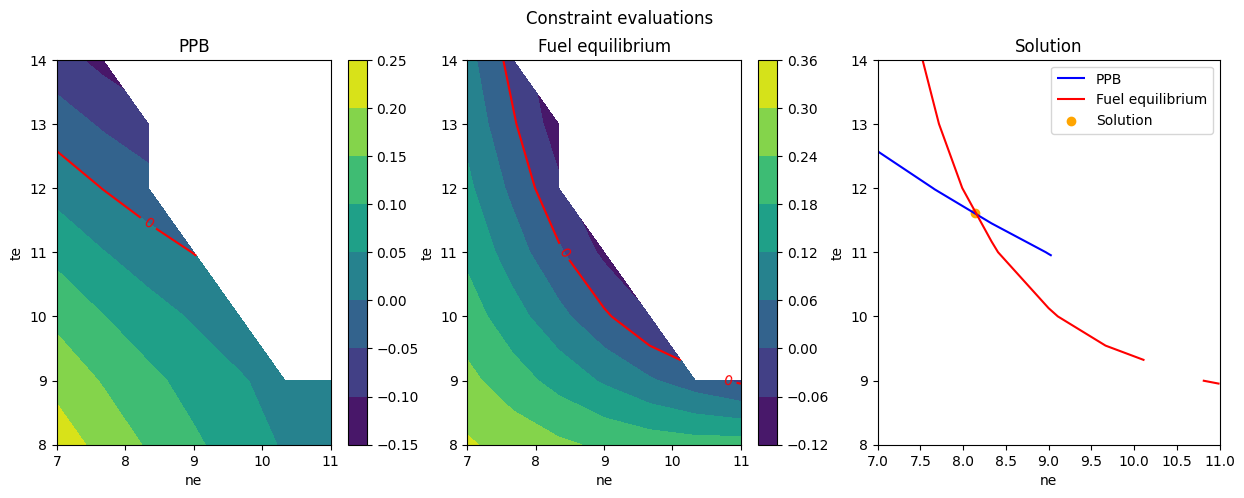

In [8]:
%matplotlib inline
fig, axs = plt.subplots(ncols=3)
fig.set_size_inches(15, 5)
contour = axs[0].contourf(
    (ne_grid * 1e-19),
    te_grid,
    con2,
)
fig.colorbar(contour, ax=axs[0])
axs[0].set_xlabel("ne")
axs[0].set_ylabel("te")
cs = axs[0].contour(
    (ne_grid * 1e-19),
    te_grid,
    con2,
    levels=[0.0],
    colors="red",
)
axs[0].clabel(cs)
# axs[0].scatter(ne_sol * 1e-19, te_sol, c="orange", label="Solution")
# axs[0].legend()

# Second plot
contour = axs[1].contourf(
    (ne_grid * 1e-19),
    te_grid,
    con93,
)
fig.colorbar(contour, ax=axs[1])
axs[1].set_xlabel("ne")
axs[1].set_ylabel("te")
cs = axs[1].contour(
    (ne_grid * 1e-19),
    te_grid,
    con93,
    levels=[0.0],
    colors="red",
)
axs[1].clabel(cs)
# axs[1].scatter(ne_sol * 1e-19, te_sol, c="orange", label="Solution")
# axs[1].legend()
axs[0].set_title("PPB")
axs[1].set_title("Fuel equilibrium")

# 3rd plot
axs[2].set_xlabel("ne")
axs[2].set_ylabel("te")
cs1 = axs[2].contour((ne_grid * 1e-19), te_grid, con2, levels=[0.0], colors="blue")
cs2 = axs[2].contour(
    (ne_grid * 1e-19),
    te_grid,
    con93,
    levels=[0.0],
    colors="red",
)
name1, label1 = cs1.legend_elements()
name2, label2 = cs2.legend_elements()
scatter = axs[2].scatter(ne_sol * 1e-19, te_sol, c="orange", label="Solution")
name3, label3 = axs[2].get_legend_handles_labels()
axs[2].legend(name1 + name2 + name3, ["PPB", "Fuel equilibrium", "Solution"])
axs[2].set_title("Solution")

fig.suptitle("Constraint evaluations")

## Control solution vector using P_inj and R_fuel

<Axes: xlabel='ne_sol', ylabel='te_sol'>

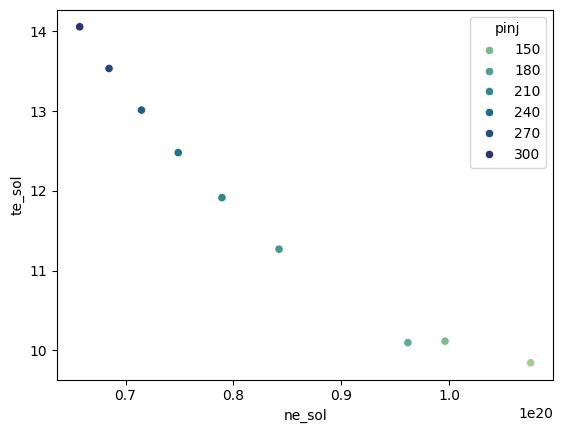

In [9]:
# Set up
INPUT_FILE = "data/lt_solve_fuel_IN.DAT"
# Initial solution vector
process.data_structure.physics_variables.nd_plasma_electrons_vol_avg = 9.0e19
process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev = 11.0

# Pinj study
sol_data = {"te_sol": [], "ne_sol": [], "pinj": []}

N = 10
pinjs = np.linspace(100.0, 300.0, N)

for pinj in pinjs:
    # Set up
    single_run = SingleRun(INPUT_FILE)
    process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
        13
    ] = 5.0e-6
    process.data_structure.physics_variables.hfact = 1.0
    process.data_structure.physics_variables.molflow_plasma_fuelling_required = (
        MOLFLOW_PLASMA_FUELLING_REQUIRED
    )

    # Modifications for each run
    process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = pinj

    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        # Insert nans for everything on failure, then add back inputs
        for key in sol_data.keys():
            sol_data[key].append(np.nan)
        sol_data["pinj"][-1] = pinj
        continue

    sol_data["pinj"].append(pinj)
    sol_data["te_sol"].append(
        process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev
    )
    sol_data["ne_sol"].append(
        process.data_structure.physics_variables.nd_plasma_electrons_vol_avg
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots()
# Filter initial points that didn't converge
sols = sol_df[sol_df["te_sol"].notnull()]
failed_sols = sol_df[sol_df["te_sol"].isnull()]
sns.scatterplot(data=sols, x="ne_sol", y="te_sol", hue="pinj", palette="crest")

Now vary the fuelling rate.

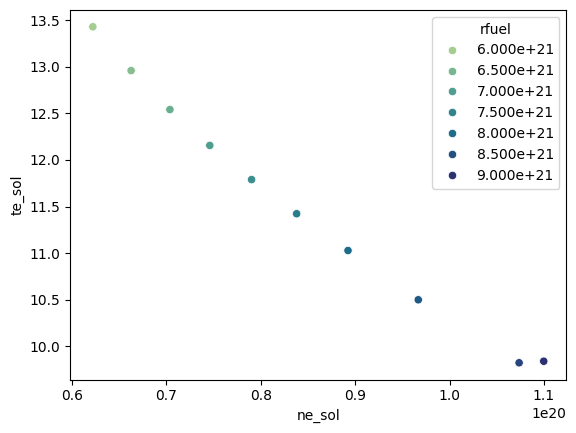

In [10]:
# Set up
INPUT_FILE = "data/lt_solve_fuel_IN.DAT"
# Initial solution vector
process.data_structure.physics_variables.nd_plasma_electrons_vol_avg = 9.0e19
process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev = 11.0

# Pinj study
sol_data = {"te_sol": [], "ne_sol": [], "rfuel": []}

N = 10
rfuels = np.linspace(6.0e21, 9.0e21, N)

for rfuel in rfuels:
    # Set up
    single_run = SingleRun(INPUT_FILE)
    process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
        13
    ] = 5.0e-6
    process.data_structure.physics_variables.hfact = 1.0
    process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = (
        P_HCD_PRIMARY_EXTRA_HEAT_MW
    )

    # Modifications for each run
    process.data_structure.physics_variables.molflow_plasma_fuelling_required = rfuel

    try:
        # Handle failed runs
        single_run.run()
    except Exception:
        # Insert nans for everything on failure, then add back inputs
        for key in sol_data.keys():
            sol_data[key].append(np.nan)
        sol_data["rfuel"][-1] = rfuel
        continue

    sol_data["rfuel"].append(rfuel)
    sol_data["te_sol"].append(
        process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev
    )
    sol_data["ne_sol"].append(
        process.data_structure.physics_variables.nd_plasma_electrons_vol_avg
    )

# Clear the lengthy stdout from multiple process runs
clear_output()

sol_df = pd.DataFrame(sol_data)
fig, ax = plt.subplots()
# Filter initial points that didn't converge
sols = sol_df[sol_df["te_sol"].notnull()]
failed_sols = sol_df[sol_df["te_sol"].isnull()]
ax = sns.scatterplot(data=sols, x="ne_sol", y="te_sol", hue="rfuel", palette="crest")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [f"{float(l):.3e}" for l in labels], title="rfuel")

## Moving the solution vector

In [11]:
# Set up
INPUT_FILE = "data/lt_solve_fuel_IN.DAT"
# Initial solution vector
process.data_structure.physics_variables.nd_plasma_electrons_vol_avg = 8.5e19
process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev = 11.5

# Pinj study
sol_data = {"te_sol": [], "ne_sol": [], "pinj": [], "rfuel": [], "error": []}

N = 100
rng = np.random.default_rng()
pinjs = rng.uniform(low=150, high=300, size=N)
rfuels = rng.uniform(low=6.0e21, high=8.5e21, size=N)

for i in range(N):
    # Set up
    single_run = SingleRun(INPUT_FILE)
    process.data_structure.impurity_radiation_module.f_nd_impurity_electron_array[
        13
    ] = 5.0e-6
    process.data_structure.physics_variables.hfact = 1.0

    # Modifications for each run
    process.data_structure.current_drive_variables.p_hcd_primary_extra_heat_mw = pinjs[
        i
    ]
    process.data_structure.physics_variables.molflow_plasma_fuelling_required = rfuels[
        i
    ]

    try:
        # Handle failed runs
        single_run.run()
    except Exception as e:
        # Insert nans for everything on failure, then add back inputs
        for key in sol_data.keys():
            sol_data[key].append(np.nan)
        sol_data["pinj"][-1] = pinjs[i]
        sol_data["rfuel"][-1] = rfuels[i]
        sol_data["error"][-1] = e
        continue

    sol_data["pinj"].append(pinjs[i])
    sol_data["rfuel"].append(rfuels[i])
    sol_data["te_sol"].append(
        process.data_structure.physics_variables.temp_plasma_electron_vol_avg_kev
    )
    sol_data["ne_sol"].append(
        process.data_structure.physics_variables.nd_plasma_electrons_vol_avg
    )
    sol_data["error"].append(None)

# Clear the lengthy stdout from multiple process runs
clear_output()

sol_df = pd.DataFrame(sol_data)


Text(0.5, 1.0, 'PPB and fuel equilibrium solutions for varying $P_{inj}$ and $R_{fuel}$')

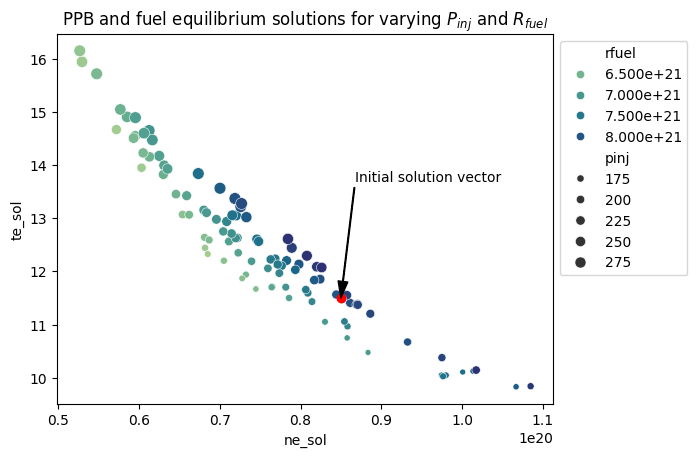

In [17]:
fig, ax = plt.subplots()
# Filter initial points that didn't converge
sols = sol_df[sol_df["te_sol"].notnull()]
failed_sols = sol_df[sol_df["te_sol"].isnull()]
ax = sns.scatterplot(
    data=sols, x="ne_sol", y="te_sol", hue="rfuel", size="pinj", palette="crest"
)
handles, labels = ax.get_legend_handles_labels()
init_sol_vec = [8.5e19, 11.5]
ax.scatter(
    init_sol_vec[0],
    init_sol_vec[1],
    c="red",
    label="Initial vector",
)
ax.annotate(
    "Initial solution vector",
    xy=init_sol_vec,
    textcoords="axes fraction",
    xytext=(0.6, 0.6),
    arrowprops=dict(facecolor="black", width=0.5, headwidth=7),
)
ax.legend(handles, [f"{float(l):.3e}" if len(l) > 7 else l for l in labels])
sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))
ax.set_title(r"PPB and fuel equilibrium solutions for varying $P_{inj}$ and $R_{fuel}$")

In [ ]:
failed_sols

,te_sol,ne_sol,pinj,rfuel,error
80,NaN,NaN,161.904882,7.480731e+21,cannot convert float NaN to integer
96,NaN,NaN,159.634513,8.297129e+21,cannot convert float NaN to integer
